In [1]:
import pickle
from main import Result
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from src import SBsimMZ
import os

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = str(node)
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=6, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()

In [3]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = [44, 1.66, 2] # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsimMZ(opt_par, action_name, capacity, om, cx, t_depl, lifetime)

In [4]:
open_file = open("/home/gkittles/SB_DRIPP_Results/4_5_25_Original_Check/results/test_results44_1.66_1.dat", "rb")
obj = pickle.load(open_file)

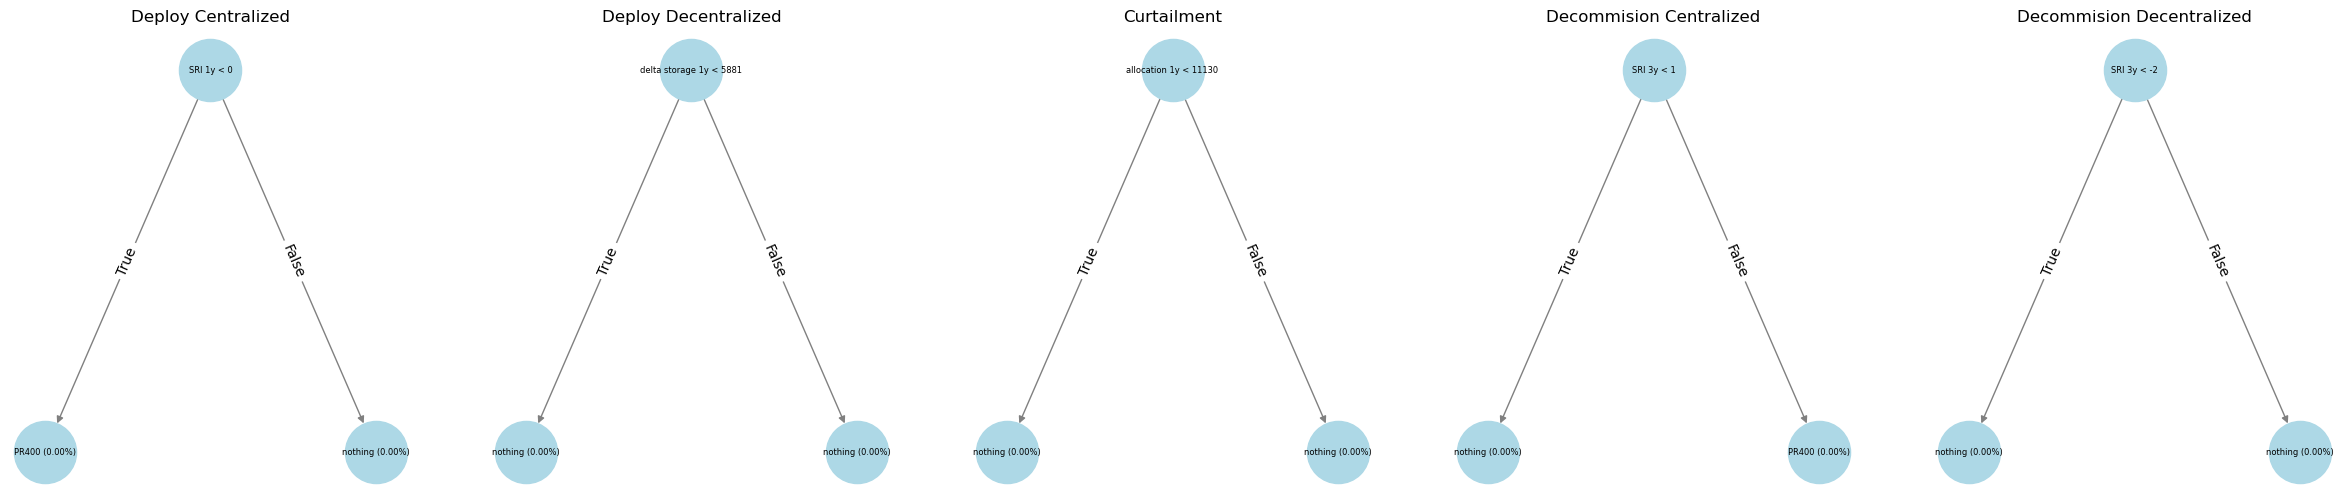

In [5]:
plot_trees(obj.best_solution)

In [6]:
log = model_sim.simulate(obj.best_solution, 3)

lake: [15000.0, 0.6976744186046512, 0, np.float64(622.62), 15000.0, np.float64(-434.3860465116279), np.float64(434.3860465116279), 0]
lake: [2000, 0.09302325581395349, np.float64(101.18), np.float64(622.62), 2000, np.float64(43.261860465116285), np.float64(57.91813953488372), 0]
lake: [4500, 0.20930232558139536, 0, np.float64(622.62), 4500, np.float64(-130.31581395348837), np.float64(130.31581395348837), 0]
sim_individual: [np.float64(14565.613953488371), np.float64(2043.2618604651163), np.float64(4369.684186046512), 0.6976744186046512, 0.09302325581395349, 0.20930232558139536, 0, np.float64(101.18), 0]
lake: [np.float64(14565.613953488371), np.float64(0.6943095214108296), 0, np.float64(569.14), np.float64(14565.613953488371), np.float64(-395.15932101575953), np.float64(395.15932101575953), 0]
lake: [np.float64(2043.2618604651163), np.float64(0.09739762216592161), np.float64(1186.9), np.float64(569.14), np.float64(2043.2618604651163), np.float64(1131.4671173204874), np.float64(55.43288

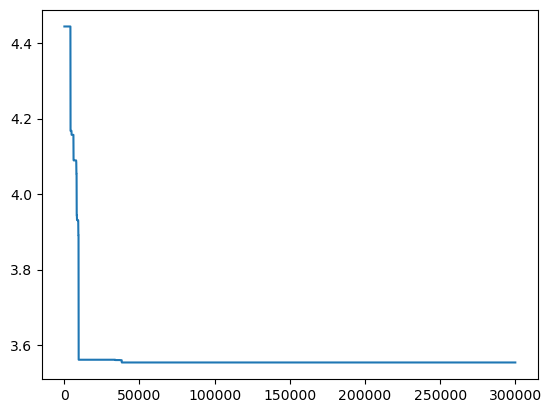

In [7]:
list = []
with open(f"/home/gkittles/SB_DRIPP_Results/4_5_25_Original_Check/slurm-62755237.out") as f:
    for line in f:
        ilist = [elt.strip() for elt in line.split('; ')]
        list.append(ilist)
nfe = []
cost = []
for val in list:
    nfe.append(int(val[0].split(" ")[1]))
    cost.append(float(val[2].split(" ")[0]))
#print(cost)
plt.plot(nfe,cost);